# Online edge inference via auxiliary regression (Tier 0+)

This notebook demonstrates **online** function → function edge inference during GSNN training using `MagnitudeEdgeRegressor`.

Instead of a post-hoc correlation pass (`MagnitudeEdgeInferer`), we fit a shared **(N, N)** weight matrix `W` as an auxiliary linear regression: activation magnitudes at layer *n−1* predict gradient magnitudes at layer *n*. Held-out edges are split into validation (early-stopping) and test sets.

Same converging-tier DAG setup as notebook 13, scaled to **12 inputs → 24 function nodes → 12 outputs** with **16 held-out** function-function edges.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
import torch

from gsnn.models.GSNN import GSNN
from gsnn.simulate.nx2pyg import nx2pyg
from gsnn.simulate.simulate import simulate
from gsnn.optim.MagnitudeEdgeInferer import MagnitudeEdgeInferer
from gsnn.optim.MagnitudeEdgeRegressor import MagnitudeEdgeRegressor

from sklearn.metrics import r2_score, roc_auc_score, roc_curve

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

%load_ext autoreload
%autoreload 2

## Build ground-truth graph G*

Same converging-tier DAG as notebook 13 (scaled 4×). Held-out edges are removed when building `G_partial`; we try to recover them online during training.

In [2]:
def build_convergence_graph(n_tier_a=6):
    n = n_tier_a
    G = nx.DiGraph()
    func_func_edges_TRUE = []

    input_nodes = [f'in{i}' for i in range(n)]
    tier_a = [f'f{i}' for i in range(n)]
    tier_b = [f'f{n + k}' for k in range(n - 1)]
    tier_c = [f'f{2 * n - 1}']
    function_nodes = tier_a + tier_b + tier_c
    output_nodes = [f'o{k}' for k in range(n)]

    for i, u in enumerate(input_nodes):
        G.add_edge(u, tier_a[i])

    for k in range(n - 1):
        b = tier_b[k]
        for parent in (tier_a[k], tier_a[k + 1]):
            e = (parent, b)
            G.add_edge(*e)
            func_func_edges_TRUE.append(e)

    sink = tier_c[0]
    for b in tier_b:
        e = (b, sink)
        G.add_edge(*e)
        func_func_edges_TRUE.append(e)

    for k, b in enumerate(tier_b):
        G.add_edge(b, output_nodes[k])
    G.add_edge(sink, output_nodes[n - 1])

    pos = {}
    x_spread = max(n - 1, 1)
    for i, u in enumerate(input_nodes):
        pos[u] = (i * 2 * x_spread / max(n - 1, 1) - x_spread, 4.0)
    for i, f in enumerate(tier_a):
        pos[f] = (i * 2 * x_spread / max(n - 1, 1) - x_spread, 3.0)
    for k, f in enumerate(tier_b):
        pos[f] = ((k + 0.5) * 2 * x_spread / max(n - 2, 1) - x_spread, 2.0)
    pos[sink] = (0.0, 1.0)
    for k, o in enumerate(output_nodes):
        pos[o] = (k * 2 * x_spread / max(n - 1, 1) - x_spread, 0.0)

    return G, pos, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE


def default_held_out_edges(n_tier_a, b2sink_stride=2):
    n = n_tier_a
    sink = f'f{2 * n - 1}'
    held = [(f'f{k}', f'f{n + k}') for k in range(1, n - 1)]
    held += [(f'f{n + k}', sink) for k in range(0, n - 1, b2sink_stride)]
    return held


N_TIER_A = 25
G, pos, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE = build_convergence_graph(
    n_tier_a=N_TIER_A,
)
N_FUNC = len(function_nodes)

HELD_OUT_EDGES = default_held_out_edges(N_TIER_A, b2sink_stride=2)
held_out_set = set(HELD_OUT_EDGES)
kept_ff_set = set(func_func_edges_TRUE) - held_out_set

assert all(G.has_edge(*e) for e in HELD_OUT_EDGES)
assert len(held_out_set & kept_ff_set) == 0

print(f'Tier-A width: {N_TIER_A}')
print(f'inputs: {len(input_nodes)} | functions: {N_FUNC} | outputs: {len(output_nodes)}')
print(f'Function-function edges: {len(func_func_edges_TRUE)}')
print(f'Held-out edges: {len(HELD_OUT_EDGES)} | kept in G_partial: {len(kept_ff_set)}')
print(f'Is DAG: {nx.is_directed_acyclic_graph(G)}')

Tier-A width: 25
inputs: 25 | functions: 50 | outputs: 25
Function-function edges: 72
Held-out edges: 35 | kept in G_partial: 37
Is DAG: True


## Simulate data

In [3]:
N_TRAIN = 2000
N_TEST = 500

x_train, x_test, y_train, y_test = simulate(
    G,
    n_train=N_TRAIN,
    n_test=N_TEST,
    input_nodes=input_nodes,
    output_nodes=output_nodes,
    noise_scale=0.15,
    special_functions=None,
)

x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

y_mu = y_train.mean(0)
y_std = y_train.std(0)
y_train = (y_train - y_mu) / (y_std + 1e-8)
y_test = (y_test - y_mu) / (y_std + 1e-8)

print('train:', x_train.shape, y_train.shape)
print('test:', x_test.shape, y_test.shape)

train: torch.Size([2000, 25]) torch.Size([2000, 25])
test: torch.Size([500, 25]) torch.Size([500, 25])


## Build partial graph G_partial

Remove held-out function-function edges. Split held-out edges into **validation** (early-stopping) and **test** sets, stratified by structural role.

In [4]:
held_out_edges = HELD_OUT_EDGES
held_out_set = set(held_out_edges)

kept_edges = [e for e in func_func_edges_TRUE if e not in held_out_set]
true_ff_set = set(func_func_edges_TRUE)

G_partial = G.copy()
G_partial.remove_edges_from(held_out_edges)
data = nx2pyg(G_partial, input_nodes, function_nodes, output_nodes)

n_non_edges = N_FUNC * (N_FUNC - 1) - len(true_ff_set)

# Stratified val/test split by structural role
sink = f'f{2 * N_TIER_A - 1}'
left_merge = [e for e in held_out_edges if e[1] != sink]
b2sink = [e for e in held_out_edges if e[1] == sink]

rng = np.random.default_rng(0)
rng.shuffle(left_merge)
rng.shuffle(b2sink)

def half_split(edges):
    n = len(edges)
    return edges[: n // 2], edges[n // 2 :]

edges_val_lm, edges_test_lm = half_split(left_merge)
edges_val_sink, edges_test_sink = half_split(b2sink)

edges_val = edges_val_lm + edges_val_sink
edges_test = edges_test_lm + edges_test_sink

print(f'Held-out function-function edges: {len(held_out_edges)}')
print(f'  val: {len(edges_val)} | test: {len(edges_test)}')
print(f'Kept function-function edges: {len(kept_edges)}')
print(f'Non-edges (true negatives): {n_non_edges}')
print(f'G_partial edges: {G_partial.number_of_edges()}')

Held-out function-function edges: 35
  val: 17 | test: 18
Kept function-function edges: 37
Non-edges (true negatives): 2378
G_partial edges: 87


## Train GSNN + online MagnitudeEdgeRegressor

Joint training loop: GSNN forward/backward, then auxiliary regression step on detached magnitudes. Validation AUC on `edges_val` selects the best checkpoint.

In [5]:
BATCH_SIZE = 64

model_kwargs = {
    'channels': 8,
    'layers': 6,
    'share_layers': False,
    'bias': True,
    'add_function_self_edges': True,
    'norm': 'none',
    'dropout': 0.2,
    'nonlin': torch.nn.ELU,
    'node_mlp': False,
    'checkpoint': False,
}

model = GSNN(
    data.edge_index_dict,
    data.node_names_dict,
    **model_kwargs,
).to(device)

regressor = MagnitudeEdgeRegressor(
    model, data,
    aggregators=('sum', 'max'),
    lr=1e-3,
    weight_decay=1e-4,
    ridge=1e-2,
    dropout=0.2,
).to(device)

print('GSNN params:', sum(p.numel() for p in model.parameters()))
print('Regressor params:', sum(p.numel() for p in regressor.parameters()))

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

gsnn_optim = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0)
crit = torch.nn.MSELoss()

n_epochs = 30
val_auc_history = []
best_epoch = None

for epoch in range(n_epochs):
    model.train()
    regressor.train()
    epoch_losses = []

    for x_batch, y_batch in train_loader:
        regressor.pre_forward()
        yhat = model(x_batch)
        loss = crit(yhat, y_batch)

        regressor.arm_retained_grads()
        gsnn_optim.zero_grad()
        loss.backward()
        regressor.aux_step()
        gsnn_optim.step()

        epoch_losses.append(loss.item())

    val_metrics = regressor.evaluate_against(edges_val)
    val_auc = val_metrics['auc']
    val_auc_history.append(val_auc)

    if regressor.maybe_save_best(val_auc):
        best_epoch = epoch + 1

    if epoch == 0 or (epoch + 1) % 1 == 0 or epoch == n_epochs - 1:
        print(
            f'epoch {epoch + 1:2d}/{n_epochs} | train loss: {np.mean(epoch_losses):.4f} '
            f'| val AUC: {val_auc:.3f} | MRR: {val_metrics["mrr"]:.3f}'
        )

model.eval()
with torch.inference_mode():
    yhat_test = model(x_test)
loss_test = crit(y_test, yhat_test)
r2_test = r2_score(y_test.detach().cpu().numpy(), yhat_test.detach().cpu().numpy())
print(f'test loss: {loss_test.item():.4f} | test r2: {r2_test:.3f}')
print(f'best val-AUC epoch: {best_epoch}')

GSNN params: 13980
Regressor params: 16480


epoch  1/30 | train loss: 0.9980 | val AUC: 0.788 | MRR: 0.198
epoch  2/30 | train loss: 0.9965 | val AUC: 0.904 | MRR: 0.365
epoch  3/30 | train loss: 0.9929 | val AUC: 0.893 | MRR: 0.407
epoch  4/30 | train loss: 0.9890 | val AUC: 0.912 | MRR: 0.410
epoch  5/30 | train loss: 0.9857 | val AUC: 0.886 | MRR: 0.417
epoch  6/30 | train loss: 0.9793 | val AUC: 0.922 | MRR: 0.416
epoch  7/30 | train loss: 0.9733 | val AUC: 0.922 | MRR: 0.484
epoch  8/30 | train loss: 0.9628 | val AUC: 0.881 | MRR: 0.482
epoch  9/30 | train loss: 0.9512 | val AUC: 0.862 | MRR: 0.570
epoch 10/30 | train loss: 0.9360 | val AUC: 0.913 | MRR: 0.571
epoch 11/30 | train loss: 0.9194 | val AUC: 0.913 | MRR: 0.602
epoch 12/30 | train loss: 0.8986 | val AUC: 0.899 | MRR: 0.601
epoch 13/30 | train loss: 0.8746 | val AUC: 0.882 | MRR: 0.630
epoch 14/30 | train loss: 0.8482 | val AUC: 0.880 | MRR: 0.630
epoch 15/30 | train loss: 0.8183 | val AUC: 0.892 | MRR: 0.630
epoch 16/30 | train loss: 0.7856 | val AUC: 0.870 | MRR

## Validation AUC vs epoch

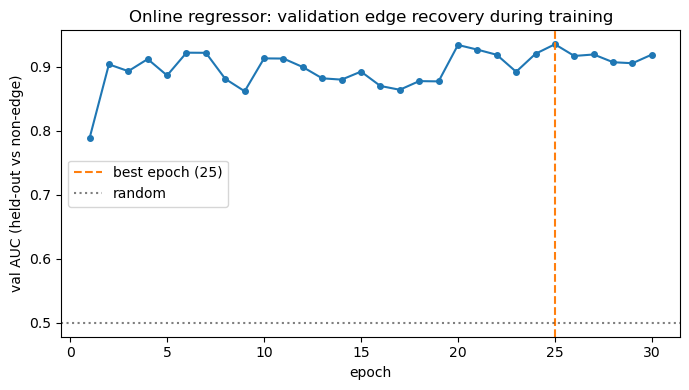

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, n_epochs + 1), val_auc_history, marker='o', ms=4)
if best_epoch is not None:
    ax.axvline(best_epoch, color='C1', ls='--', label=f'best epoch ({best_epoch})')
ax.axhline(0.5, color='k', ls=':', alpha=0.5, label='random')
ax.set_xlabel('epoch')
ax.set_ylabel('val AUC (held-out vs non-edge)')
ax.set_title('Online regressor: validation edge recovery during training')
ax.legend()
plt.tight_layout()
plt.show()

## Compare regressor (best checkpoint) vs post-hoc MagnitudeEdgeInferer

Load the best regressor checkpoint, then run post-hoc `MagnitudeEdgeInferer` on the final GSNN for head-to-head comparison on **test** held-out edges.

In [12]:
regressor.load_best()
res_reg = regressor.evaluate()

# Post-hoc MEI on final model
MEI = MagnitudeEdgeInferer(model, data, reduction='l1')
infer_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)
MEI.fit(infer_loader, crit=crit, device=device, verbose=False)
res_corr = MEI.evaluate(layer_agg='max', score='corr')
res_partial = MEI.evaluate(layer_agg='max', score='partial')

print('Top 10 regressor scores:')
print(res_reg[['src_func', 'dst_func', 'score', 'has_edge', 'q_value']].head(10).to_string())

Top 10 regressor scores:
  src_func dst_func     score  has_edge   q_value
0       f1      f26  0.461439     False  0.527687
1      f22      f47  0.400908     False  0.527687
2      f16      f41  0.400895     False  0.527687
3       f6      f31  0.398516     False  0.527687
4      f23      f48  0.397042     False  0.527687
5       f2      f27  0.395549     False  0.527687
6      f12      f37  0.394976     False  0.527687
7      f18      f43  0.392816     False  0.527687
8      f14      f39  0.390867     False  0.527687
9       f8      f33  0.388819     False  0.527687


In [13]:
print(res_reg[['src_func', 'dst_func', 'score', 'has_edge', 'q_value']].tail(10).to_string())

     src_func dst_func     score  has_edge   q_value
2440       f7      f36  0.000032     False  0.527687
2441      f17      f23  0.000031     False  0.527687
2442      f31      f29  0.000030     False  0.527687
2443       f5       f7  0.000025     False  0.527687
2444      f38      f44  0.000020     False  0.527687
2445      f44      f34  0.000015     False  0.527687
2446       f0      f18  0.000008     False  0.527687
2447      f25      f19  0.000003     False  0.527687
2448      f45       f2  0.000003     False  0.527687
2449      f31      f39  0.000002     False  0.527687


## Test-set ROC comparison

In [14]:
def roc_auc_for_edges(res_df, positive_edges, score_col='score'):
    pos_set = set(positive_edges)
    pos = res_df[res_df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)][score_col].dropna().values
    neg = res_df[~res_df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)]
    neg = neg[neg.apply(lambda r: (r['src_func'], r['dst_func']) not in kept_ff_set, axis=1)][score_col].dropna().values
    if len(pos) == 0 or len(neg) == 0:
        return float('nan')
    y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
    y_score = np.concatenate([pos, neg])
    return roc_auc_score(y_true, y_score)


def print_target_ranking(label, res_df, positive_edges):
    detail, summary = MagnitudeEdgeRegressor.evaluate_target_ranking(
        res_df, positive_edges=positive_edges, score_col='score' if 'score' in res_df.columns else 'corr',
    )
    print(f'=== {label} ===')
    print(f"  MRR: {summary['mrr']:.3f}  top@1: {summary['top@1']:.3f}  top@3: {summary['top@3']:.3f}")
    return summary

kept_set = set(kept_edges)

results = {
    'regressor (best)': (res_reg, 'score'),
    'MEI corr': (res_corr, 'corr'),
    'MEI partial': (res_partial, 'corr'),
}

print('Test-set ROC-AUC (held-out test vs non-edges):')
for name, (df, col) in results.items():
    auc = roc_auc_for_edges(df, edges_test, score_col=col)
    print(f'  {name:20s}: AUC = {auc:.3f}')

print()
for name, (df, col) in results.items():
    if col != 'score':
        df = df.rename(columns={'corr': 'score'})
    print_target_ranking(name, df, edges_test)

Test-set ROC-AUC (held-out test vs non-edges):
  regressor (best)    : AUC = 0.961
  MEI corr            : AUC = 0.969
  MEI partial         : AUC = 0.970

=== regressor (best) ===
  MRR: 0.687  top@1: 0.667  top@3: 0.667
=== MEI corr ===
  MRR: 0.707  top@1: 0.667  top@3: 0.667
=== MEI partial ===
  MRR: 0.707  top@1: 0.667  top@3: 0.667


## ROC curves on test held-out edges

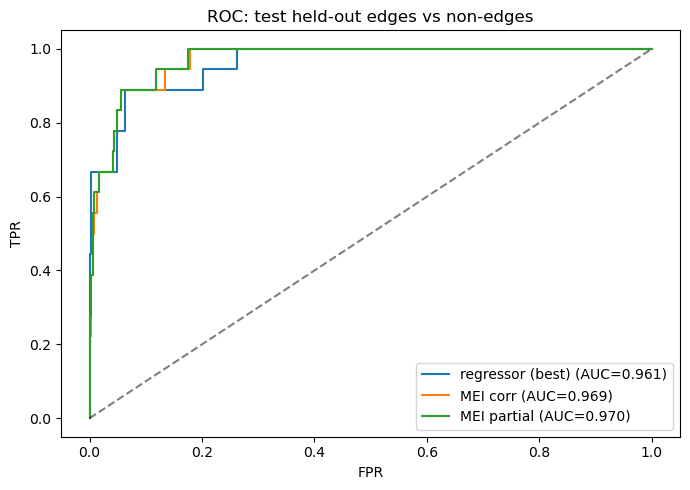

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, (df, col) in results.items():
    pos_set = set(edges_test)
    pos = df[df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)][col].dropna().values
    neg = df[~df.apply(lambda r: (r['src_func'], r['dst_func']) in pos_set, axis=1)]
    neg = neg[neg.apply(lambda r: (r['src_func'], r['dst_func']) not in kept_ff_set, axis=1)][col].dropna().values
    if len(pos) == 0 or len(neg) == 0:
        continue
    y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
    y_score = np.concatenate([pos, neg])
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC: test held-out edges vs non-edges')
ax.legend()
plt.tight_layout()
plt.show()

## Discussion

`MagnitudeEdgeRegressor` trains a shared **(N, N)** weight matrix online during GSNN training. Unlike post-hoc correlation (`MagnitudeEdgeInferer`), it:

1. **Reuses the training forward/backward** — no extra pass over the data.
2. **Multivariate regression** — each target gradient magnitude is predicted from all source activations, conditioning on other sources automatically (partial-correlation-like).
3. **Validation early-stopping** — held-out edges drive checkpoint selection, mitigating **gradient absorption** at equilibrium (see `docs/notes/edge_inference_notes.md` §4.5 / §7.1).

The val-AUC vs epoch plot should show a peak **before** full convergence, when missing edges still produce informative gradient signal.